In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.activations import relu,softmax
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [3]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


In [4]:
print(x_train.shape)

(60000, 28, 28)


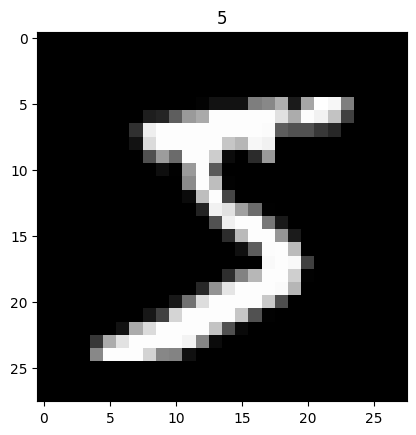

In [6]:
plt.imshow(x_train[0],cmap = 'gray')
plt.title(y_train[0])
plt.show()

In [9]:
x_train = x_train/255.0
x_test = x_test/255.0

In [15]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9164 - loss: 0.2834 - val_accuracy: 0.9602 - val_loss: 0.1378
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9651 - loss: 0.1170 - val_accuracy: 0.9645 - val_loss: 0.1186
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9745 - loss: 0.0838 - val_accuracy: 0.9681 - val_loss: 0.1057
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9804 - loss: 0.0628 - val_accuracy: 0.9695 - val_loss: 0.1021
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9831 - loss: 0.0507 - val_accuracy: 0.9732 - val_loss: 0.0964
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9868 - loss: 0.0414 - val_accuracy: 0.9752 - val_loss: 0.0956
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9886 - loss: 0.0342 - val_accuracy: 0.9742 - val_loss: 0.0996
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9900 -

In [16]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9745 - loss: 0.1117
Test Loss: 0.11169091612100601
Test Accuracy: 0.9745000004768372


In [17]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
predicted_digits = np.argmax(predictions,axis = 1)
print("Predicted:", predicted_digits[:10])
print("Actual   :", y_test[:10])

Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual   : [7 2 1 0 4 1 4 9 5 9]


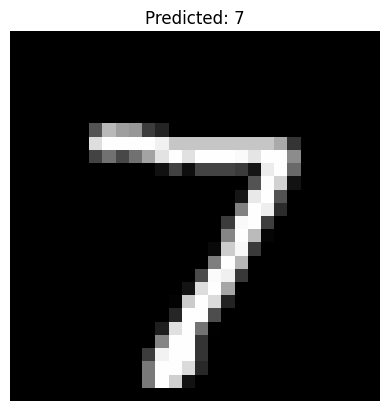

In [20]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_digits[0]}")
plt.axis("off")
plt.show()

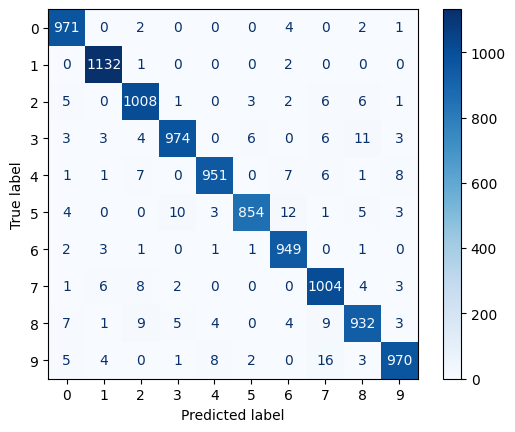

In [21]:
cm = confusion_matrix(y_test,predicted_digits)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [22]:
print(classification_report(y_test,predicted_digits))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.98      0.96      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.96      0.97       892
           6       0.97      0.99      0.98       958
           7       0.96      0.98      0.97      1028
           8       0.97      0.96      0.96       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



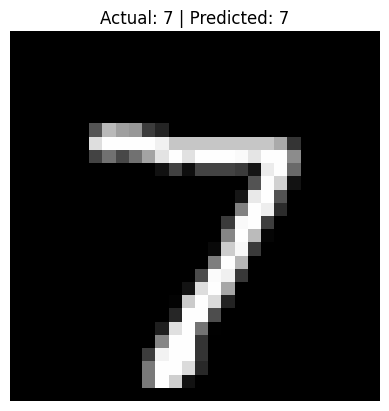

In [24]:
index = 0

plt.imshow(x_test[index], cmap='gray')
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_digits[index]}")
plt.axis('off')
plt.show()

In [26]:
wrong_predictions = np.where(predicted_digits != y_test)[0]

In [27]:
print("Total Wrong Predictions:", len(wrong_predictions))

Total Wrong Predictions: 255


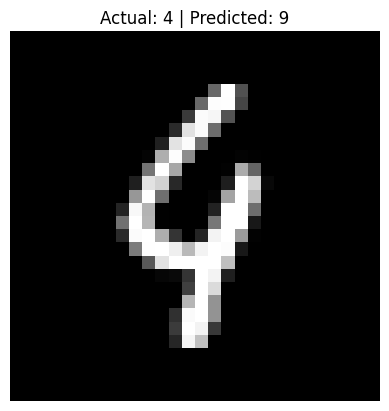

In [28]:
index = wrong_predictions[0]

plt.imshow(x_test[index], cmap='gray')
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_digits[index]}")
plt.axis('off')
plt.show()

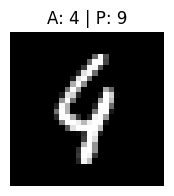

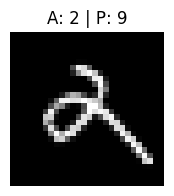

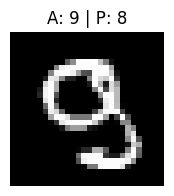

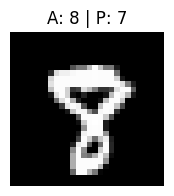

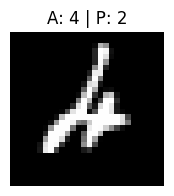

In [29]:
for i in range(5):
    index = wrong_predictions[i]

    plt.figure(figsize=(2,2))
    plt.imshow(x_test[index], cmap='gray')
    plt.title(f"A: {y_test[index]} | P: {predicted_digits[index]}")
    plt.axis('off')
    plt.show()